# **Optimización analítica y métodos numéricos con `SymPy`, `NumPy` y `Matplotlib`**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/calculo_simbolico/sympy_optimizacion.ipynb)

**Profesor:** Francisco Pérez M. · **Propedéutico de Matemáticas y Programación · FLACSO Ecuador**

## De $\mathbb{R}\to\mathbb{R}$ a $\mathbb{R}^n\to\mathbb{R}^m$

Este notebook presenta una ruta progresiva para estudiantes que utilizan por primera vez `sympy`, `numpy` y `matplotlib`.

La organización separa deliberadamente dos enfoques:

1. **Ruta principal: optimización analítica.** Se calculan derivadas, se resuelven las condiciones de primer orden y se clasifican los puntos mediante condiciones de segundo orden.
2. **Módulo opcional: métodos numéricos.** Al final se introduce descenso o ascenso por gradiente para problemas que no admiten una solución analítica sencilla.

## Objetivos de aprendizaje

Al finalizar, el estudiante podrá:

- reconocer las dimensiones de escalares, vectores, Jacobianas y Hessianas;
- comprobar si un producto matricial está bien conformado;
- usar Taylor de primer y segundo orden;
- interpretar la linealización como recta o hiperplano tangente;
- aplicar CPO y CSO en $\mathbb{R}\to\mathbb{R}$ y $\mathbb{R}^n\to\mathbb{R}$;
- clasificar Hessianas mediante formas cuadráticas, menores principales líderes y autovalores;
- resolver ejemplos económicos con `sympy` y graficarlos con `matplotlib`;
- escalarizar una función $\mathbb{R}^n\to\mathbb{R}^m$;
- comprender por qué los métodos de gradiente son útiles en redes neuronales.

> **Nivel:** introductorio. Los comandos se repiten de manera deliberada y cada cálculo se acompaña de su dimensión.

## Preparación del entorno

### Google Colab

Las bibliotecas suelen estar instaladas. Si aparece un error, ejecute una sola vez:

```python
%pip install sympy numpy matplotlib
```

### VS Code

**Windows — PowerShell**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install sympy numpy matplotlib ipykernel
```

**macOS o Linux**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install sympy numpy matplotlib ipykernel
```

En VS Code, abra el notebook y seleccione como kernel el intérprete de `.venv`.

In [1]:
# Ejecute esta celda solo si necesita instalar las bibliotecas.
# Quite el símbolo # de la línea siguiente y ejecútela una sola vez.
# %pip install sympy numpy matplotlib


In [2]:
%matplotlib inline

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Presentación matemática de las expresiones simbólicas.
sp.init_printing(use_latex='mathjax')


# 0. Mapa dimensional de los objetos

Sea

$$
f:\mathbb{R}^n\longrightarrow\mathbb{R}^m,
\qquad
\mathbf{x}\longmapsto f(\mathbf{x}).
$$

Adoptaremos estas convenciones:

- $\mathbf{x}$ es un vector columna de dimensión $n\times 1$;
- $f(\mathbf{x})$ es un vector columna de dimensión $m\times 1$;
- el gradiente de una función escalar es un vector columna;
- la Jacobiana coloca en cada fila el gradiente transpuesto de una componente.

| Objeto | Notación | Dimensión |
|---|---|---:|
| Variable de decisión | $\mathbf{x}$ | $n\times1$ |
| Incremento | $\mathbf{h}$ | $n\times1$ |
| Valor vectorial | $f(\mathbf{x})$ | $m\times1$ |
| Jacobiana | $J_f(\mathbf{x})$ | $m\times n$ |
| Hessiana de $f_i$ | $H_{f_i}(\mathbf{x})$ | $n\times n$ |
| Segunda derivada vectorial | $D^2f$ | tensor $m\times n\times n$ |
| Pesos | $\mathbf{w}$ | $m\times1$ |

Para una función escalar $F:\mathbb{R}^n\to\mathbb{R}$:

| Objeto | Notación | Dimensión |
|---|---|---:|
| Valor | $F(\mathbf{x})$ | escalar $1\times1$ |
| Gradiente | $\nabla F(\mathbf{x})$ | $n\times1$ |
| Jacobiana de $F$ | $J_F=\nabla F^T$ | $1\times n$ |
| Hessiana | $H_F(\mathbf{x})$ | $n\times n$ |

## Regla de compatibilidad

Si $A$ tiene dimensión $p\times q$ y $B$ tiene dimensión $q\times r$, entonces

$$
AB\in\mathbb{R}^{p\times r}.
$$

Las **dimensiones interiores** deben coincidir.

## 0.1. Productos que aparecerán en el notebook

| Expresión | Dimensiones | Resultado |
|---|---|---:|
| $J_f\mathbf{h}$ | $(m\times n)(n\times1)$ | $m\times1$ |
| $\nabla F^T\mathbf{h}$ | $(1\times n)(n\times1)$ | escalar |
| $\mathbf{h}^TH_F\mathbf{h}$ | $(1\times n)(n\times n)(n\times1)$ | escalar |
| $\mathbf{w}^Tf$ | $(1\times m)(m\times1)$ | escalar |
| $J_f^T\mathbf{w}$ | $(n\times m)(m\times1)$ | $n\times1$ |

Esta revisión dimensional evita errores como intentar restar una matriz Jacobiana $m\times n$ a un vector $n\times1$.

In [3]:
# Pequeña comprobación de dimensiones con matrices simbólicas.
n_demo = 3
m_demo = 2

J_demo = sp.zeros(m_demo, n_demo)   # 2 x 3
h_demo = sp.zeros(n_demo, 1)       # 3 x 1
w_demo = sp.zeros(m_demo, 1)       # 2 x 1
H_demo = sp.eye(n_demo)            # 3 x 3

print('J_demo:', J_demo.shape)
print('h_demo:', h_demo.shape)
print('J_demo * h_demo:', (J_demo * h_demo).shape)
print('J_demo.T * w_demo:', (J_demo.T * w_demo).shape)
print('h_demo.T * H_demo * h_demo:', (h_demo.T * H_demo * h_demo).shape)


J_demo: (2, 3)
h_demo: (3, 1)
J_demo * h_demo: (2, 1)
J_demo.T * w_demo: (3, 1)
h_demo.T * H_demo * h_demo: (1, 1)


# 1. Funciones escalares $f:\mathbb{R}\to\mathbb{R}$

## 1.1. Aproximaciones de Taylor

Sea $x_0$ un punto base y $h$ un incremento pequeño.

### Primer orden

$$
\boxed{
f(x_0+h)=f(x_0)+f'(x_0)h+o(|h|)
}
$$

La linealización es

$$
\boxed{
L(x)=f(x_0)+f'(x_0)(x-x_0)
}
$$

y representa la **recta tangente** a la gráfica de $f$ en $x_0$.

### Segundo orden

$$
\boxed{
f(x_0+h)
=f(x_0)+f'(x_0)h+\frac12 f''(x_0)h^2+o(h^2)
}
$$

El término $f'(x_0)h$ describe la pendiente local y el término $\frac12f''(x_0)h^2$ incorpora la curvatura.

## 1.2. Condiciones de primer y segundo orden

Si $x^*$ es un óptimo local interior y $f$ es diferenciable, la **condición necesaria de primer orden** es

$$
\boxed{f'(x^*)=0.}
$$

En un punto crítico:

| Segunda derivada | Conclusión |
|---|---|
| $f''(x^*)>0$ | mínimo local estricto |
| $f''(x^*)<0$ | máximo local estricto |
| $f''(x^*)=0$ | criterio inconcluso |

Como condiciones necesarias de segundo orden:

- en un mínimo local, $f''(x^*)\ge 0$;
- en un máximo local, $f''(x^*)\le 0$.

Los signos estrictos constituyen condiciones suficientes.

## 1.3. Aplicación: beneficio de una empresa

Una empresa enfrenta

$$
p(q)=50-q,
\qquad
C(q)=10q+100.
$$

El beneficio es

$$
\pi(q)=p(q)q-C(q).
$$

Buscaremos la cantidad $q^*$ que maximiza el beneficio.

In [4]:
# Variable simbólica.
q = sp.symbols('q', real=True)

# Precio, ingreso, costo y beneficio.
precio = 50 - q
ingreso = precio*q
costo = 10*q + 100
beneficio_q = sp.expand(ingreso - costo)

print('Beneficio:')
display(beneficio_q)


Beneficio:


   2             
- q  + 40⋅q - 100

In [5]:
# Primera y segunda derivadas.
beneficio_q_1 = sp.diff(beneficio_q, q)
beneficio_q_2 = sp.diff(beneficio_q, q, 2)

# Condición de primer orden.
soluciones_q = sp.solve(beneficio_q_1, q)
q_star = soluciones_q[0]

# Clasificación.
segunda_en_q_star = sp.simplify(beneficio_q_2.subs(q, q_star))

if segunda_en_q_star > 0:
    clasificacion_q = 'mínimo local'
elif segunda_en_q_star < 0:
    clasificacion_q = 'máximo local'
else:
    clasificacion_q = 'criterio inconcluso'

beneficio_star_q = sp.simplify(beneficio_q.subs(q, q_star))

print("pi'(q) =")
display(beneficio_q_1)
print("pi''(q) =")
display(beneficio_q_2)
print('q* =', q_star)
print('Clasificación:', clasificacion_q)
print('Beneficio máximo =', beneficio_star_q)

assert q_star == 20
assert beneficio_star_q == 300


pi'(q) =


40 - 2⋅q

pi''(q) =


-2

q* = 20
Clasificación: máximo local
Beneficio máximo = 300


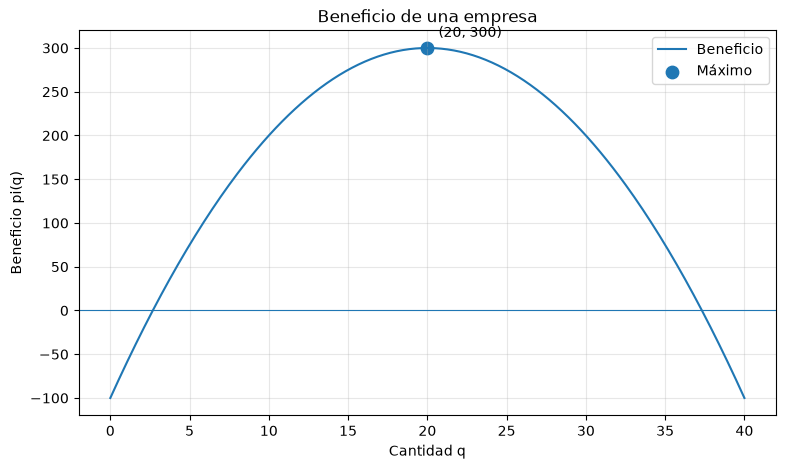

In [6]:
# Convertimos la expresión simbólica en una función numérica.
beneficio_q_np = sp.lambdify(q, beneficio_q, 'numpy')

q_valores = np.linspace(0, 40, 300)
pi_valores = beneficio_q_np(q_valores)

plt.figure(figsize=(9, 5))
plt.plot(q_valores, pi_valores, label='Beneficio')
plt.scatter(float(q_star), float(beneficio_star_q), s=80, label='Máximo')
plt.annotate('(20, 300)', (float(q_star), float(beneficio_star_q)),
             xytext=(8, 8), textcoords='offset points')
plt.axhline(0, linewidth=0.8)
plt.title('Beneficio de una empresa')
plt.xlabel('Cantidad q')
plt.ylabel('Beneficio pi(q)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# 2. Funciones multivariadas $F:\mathbb{R}^n\to\mathbb{R}$

## 2.1. Aproximación de primer orden e hiperplano tangente

Sean

$$
\mathbf{x}_0\in\mathbb{R}^n,
\qquad
\mathbf{h}\in\mathbb{R}^n.
$$

Si $F$ es diferenciable,

$$
\boxed{
F(\mathbf{x}_0+\mathbf{h})
=F(\mathbf{x}_0)
+\nabla F(\mathbf{x}_0)^T\mathbf{h}
+o(\|\mathbf{h}\|)
}
$$

La linealización alrededor de $\mathbf{x}_0$ es

$$
\boxed{
L(\mathbf{x})
=F(\mathbf{x}_0)
+\nabla F(\mathbf{x}_0)^T(\mathbf{x}-\mathbf{x}_0)
}
$$

Geométricamente, $L$ es el **hiperplano tangente** a la gráfica de $F$ en el punto $(\mathbf{x}_0,F(\mathbf{x}_0))\in\mathbb{R}^{n+1}$.

Comprobación dimensional:

$$
\underbrace{\nabla F(\mathbf{x}_0)^T}_{1\times n}
\underbrace{(\mathbf{x}-\mathbf{x}_0)}_{n\times1}
\;\in\;\mathbb{R}.
$$

Esta aproximación lineal será la base de los métodos de gradiente que se presentan, de forma opcional, al final.

## 2.2. Aproximación de segundo orden y forma cuadrática

Si $F$ tiene segundas derivadas continuas,

$$
\boxed{
F(\mathbf{x}_0+\mathbf{h})
=F(\mathbf{x}_0)
+\nabla F(\mathbf{x}_0)^T\mathbf{h}
+\frac12\mathbf{h}^TH_F(\mathbf{x}_0)\mathbf{h}
+o(\|\mathbf{h}\|^2)
}
$$

El término

$$
\boxed{Q(\mathbf{h})=\mathbf{h}^TH_F(\mathbf{x}_0)\mathbf{h}}
$$

es una **forma cuadrática**. Su signo describe la curvatura local.

Dimensiones:

$$
\underbrace{\mathbf{h}^T}_{1\times n}
\underbrace{H_F}_{n\times n}
\underbrace{\mathbf{h}}_{n\times1}
\;\in\;\mathbb{R}.
$$

La aproximación de segundo orden es la base del método de Newton, porque utiliza tanto el gradiente como la Hessiana.

## 2.3. Condiciones de optimización sin restricciones

### Condición necesaria de primer orden

Si $\mathbf{x}^*$ es un óptimo local interior y $F$ es diferenciable,

$$
\boxed{\nabla F(\mathbf{x}^*)=\mathbf{0}.}
$$

Esta ecuación produce **candidatos**. No clasifica por sí sola.

### Condiciones de segundo orden

En un punto crítico, el término lineal desaparece y

$$
F(\mathbf{x}^*+\mathbf{h})-F(\mathbf{x}^*)
\approx
\frac12\mathbf{h}^TH_F(\mathbf{x}^*)\mathbf{h}.
$$

| Hessiana | Signo de $Q(\mathbf{h})$ | Clasificación |
|---|---|---|
| $H_F\succ0$ | positivo para todo $\mathbf{h}\ne0$ | mínimo local estricto |
| $H_F\prec0$ | negativo para todo $\mathbf{h}\ne0$ | máximo local estricto |
| indefinida | positivo en unas direcciones y negativo en otras | punto de silla |
| semidefinida | puede ser cero en direcciones no nulas | prueba inconclusa |

Condiciones necesarias:

- en un mínimo local, $H_F(\mathbf{x}^*)$ debe ser semidefinida positiva;
- en un máximo local, debe ser semidefinida negativa.

Condiciones suficientes estrictas:

- $H_F(\mathbf{x}^*)\succ0\Rightarrow$ mínimo local estricto;
- $H_F(\mathbf{x}^*)\prec0\Rightarrow$ máximo local estricto.

## 2.4. Criterio analítico: menores principales líderes

Sea $H$ una matriz Hessiana simétrica de dimensión $n\times n$. Definimos

$$
\Delta_k=\det(H_k),
$$

donde $H_k$ es el bloque superior izquierdo de dimensión $k\times k$.

Estos determinantes se llaman **menores principales líderes**.

### Matriz definida positiva

$$
H\succ0
\quad\Longleftrightarrow\quad
\Delta_1>0,\Delta_2>0,\ldots,\Delta_n>0.
$$

### Matriz definida negativa

$$
H\prec0
\quad\Longleftrightarrow\quad
\Delta_1<0,\Delta_2>0,\Delta_3<0,\ldots
$$

Equivalentemente,

$$
(-1)^k\Delta_k>0,
\qquad k=1,\ldots,n.
$$

> **Precisión importante:** si falla uno de estos dos patrones, no se puede concluir inmediatamente que la matriz sea indefinida. También podría ser semidefinida. Para matrices semidefinidas se requiere revisar todos los menores principales o utilizar autovalores.

## 2.5. Criterio computacional: autovalores

Para una Hessiana simétrica:

| Autovalores | Clasificación de $H$ |
|---|---|
| todos $\lambda_i>0$ | definida positiva |
| todos $\lambda_i<0$ | definida negativa |
| algunos positivos y otros negativos | indefinida |
| aparecen ceros y no hay mezcla de signos | semidefinida o caso degenerado |

En `NumPy` utilizaremos

```python
np.linalg.eigvalsh(H)
```

porque `eigvalsh` está diseñado para matrices simétricas.

### Tolerancia numérica

En cálculo simbólico, un autovalor puede ser exactamente cero. En cálculo numérico, el mismo valor podría aparecer como $10^{-16}$ o $-10^{-16}$ por efectos del punto flotante. Por ello no conviene comparar directamente con cero.

Usaremos una tolerancia

```python
tol = 1e-8
```

e interpretaremos:

- $\lambda_i>\texttt{tol}$ como positivo;
- $\lambda_i<-\texttt{tol}$ como negativo;
- $|\lambda_i|\leq\texttt{tol}$ como numéricamente cero.

Los menores líderes son útiles para el cálculo manual; los autovalores, evaluados con tolerancia, son una comprobación computacional robusta de las direcciones de curvatura.



## 2.6. Caso particular $\mathbb{R}^2\to\mathbb{R}$

Si

$$
H_F=
\begin{pmatrix}
F_{xx} & F_{xy}\\
F_{yx} & F_{yy}
\end{pmatrix},
$$

los menores líderes son

$$
\Delta_1=F_{xx},
\qquad
\Delta_2=\det(H_F)=D.
$$

Por tanto:

| Condición | Clasificación |
|---|---|
| $D>0$ y $F_{xx}>0$ | mínimo local |
| $D>0$ y $F_{xx}<0$ | máximo local |
| $D<0$ | punto de silla |
| $D=0$ | criterio inconcluso |

El criterio conocido del determinante en dos variables es, por tanto, un caso particular del criterio general de menores líderes.

## 2.7. Convexidad y concavidad

En un dominio convexo:

- si $H_F(\mathbf{x})\succeq0$ para todo $\mathbf{x}$, entonces $F$ es convexa;
- si $H_F(\mathbf{x})\succ0$ para todo $\mathbf{x}$, entonces $F$ es estrictamente convexa;
- si $H_F(\mathbf{x})\preceq0$ para todo $\mathbf{x}$, entonces $F$ es cóncava;
- si $H_F(\mathbf{x})\prec0$ para todo $\mathbf{x}$, entonces $F$ es estrictamente cóncava.

Consecuencias:

- en una función convexa, cualquier mínimo local es global;
- en una función estrictamente convexa, el mínimo global es único;
- en una función cóncava, cualquier máximo local es global;
- en una función estrictamente cóncava, el máximo global es único.

# 3. Aplicaciones económicas multivariadas

## 3.1. Empresa con dos productos: $\mathbb{R}^2\to\mathbb{R}$

Una empresa produce dos bienes, $x$ e $y$, y obtiene

$$
\pi(x,y)=26x+22y-2x^2-2y^2-2xy.
$$

Aplicaremos el mismo orden lógico:

1. gradiente y CPO;
2. Hessiana;
3. menores principales líderes;
4. autovalores;
5. clasificación y gráfica.

In [7]:
# Variables simbólicas.
x, y = sp.symbols('x y', real=True)
variables_2 = (x, y)

# Función de beneficio.
beneficio_2 = 26*x + 22*y - 2*x**2 - 2*y**2 - 2*x*y

# Gradiente columna: 2 x 1.
grad_beneficio_2 = sp.Matrix([
    sp.diff(beneficio_2, x),
    sp.diff(beneficio_2, y)
])

print('Función de beneficio:')
display(beneficio_2)
print('Gradiente:')
display(grad_beneficio_2)
print('Dimensión del gradiente:', grad_beneficio_2.shape)


Función de beneficio:


     2                     2       
- 2⋅x  - 2⋅x⋅y + 26⋅x - 2⋅y  + 22⋅y

Gradiente:


⎡-4⋅x - 2⋅y + 26⎤
⎢               ⎥
⎣-2⋅x - 4⋅y + 22⎦

Dimensión del gradiente: (2, 1)


In [8]:
# Condiciones de primer orden.
soluciones_2 = sp.solve(
    list(grad_beneficio_2),
    variables_2,
    dict=True
)
solucion_2 = soluciones_2[0]

print('Punto crítico:')
display(solucion_2)


Punto crítico:


{x: 5, y: 3}

In [9]:
# Hessiana: 2 x 2.
H_beneficio_2 = sp.hessian(beneficio_2, variables_2)
H_2_critico = H_beneficio_2.subs(solucion_2)

# Menores principales líderes.
Delta1_2 = sp.simplify(H_2_critico[:1, :1].det())
Delta2_2 = sp.simplify(H_2_critico[:2, :2].det())

print('Hessiana:')
display(H_2_critico)
print('Dimensión de la Hessiana:', H_2_critico.shape)
print('Delta_1 =', Delta1_2)
print('Delta_2 =', Delta2_2)

# Criterio manual para dos variables.
if Delta2_2 > 0 and Delta1_2 > 0:
    clasificacion_menores_2 = 'mínimo local'
elif Delta2_2 > 0 and Delta1_2 < 0:
    clasificacion_menores_2 = 'máximo local'
elif Delta2_2 < 0:
    clasificacion_menores_2 = 'punto de silla'
else:
    clasificacion_menores_2 = 'criterio inconcluso'

print('Clasificación por menores:', clasificacion_menores_2)


Hessiana:


⎡-4  -2⎤
⎢      ⎥
⎣-2  -4⎦

Dimensión de la Hessiana: (2, 2)
Delta_1 = -4
Delta_2 = 12
Clasificación por menores: máximo local


In [10]:
# Comprobación computacional con autovalores y tolerancia.
H_2_np = np.array(H_2_critico.tolist(), dtype=float)
autovalores_2 = np.linalg.eigvalsh(H_2_np)
tol = 1e-8

if np.all(autovalores_2 > tol):
    clasificacion_autovalores_2 = 'mínimo local estricto'
elif np.all(autovalores_2 < -tol):
    clasificacion_autovalores_2 = 'máximo local estricto'
elif np.any(autovalores_2 > tol) and np.any(autovalores_2 < -tol):
    clasificacion_autovalores_2 = 'punto de silla'
else:
    clasificacion_autovalores_2 = 'semidefinida o criterio inconcluso'

beneficio_star_2 = sp.simplify(beneficio_2.subs(solucion_2))
x_star_2 = solucion_2[x]
y_star_2 = solucion_2[y]

print('Autovalores:', autovalores_2)
print('Tolerancia numérica:', tol)
print('Clasificación por autovalores:', clasificacion_autovalores_2)
print('x* =', x_star_2)
print('y* =', y_star_2)
print('Beneficio máximo =', beneficio_star_2)

assert solucion_2 == {x: 5, y: 3}
assert beneficio_star_2 == 98
assert clasificacion_autovalores_2 == 'máximo local estricto'


Autovalores: [-6. -2.]
Tolerancia numérica: 1e-08
Clasificación por autovalores: máximo local estricto
x* = 5
y* = 3
Beneficio máximo = 98


La Hessiana es negativa definida en todo punto. Por ello, $\pi$ es estrictamente cóncava y $(5,3)$ es el **máximo global único**.

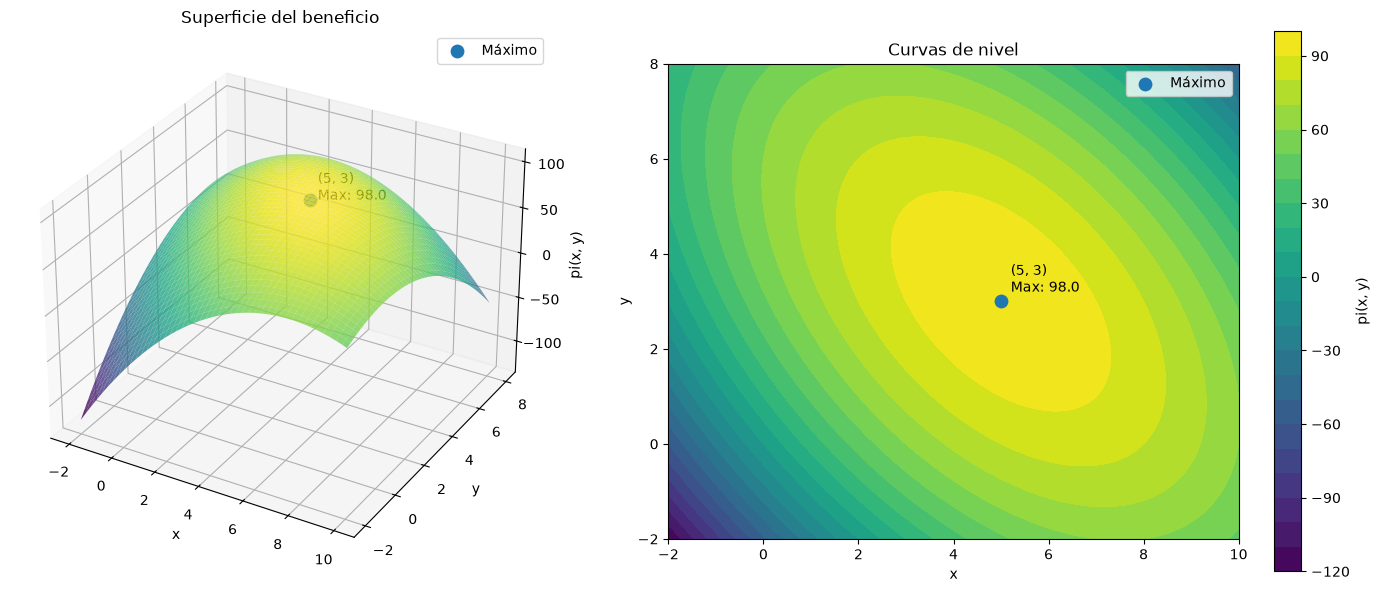

In [11]:
# Función numérica para las gráficas.
beneficio_2_np = sp.lambdify((x, y), beneficio_2, 'numpy')

x_valores = np.linspace(-2, 10, 180)
y_valores = np.linspace(-2, 8, 180)
X, Y = np.meshgrid(x_valores, y_valores)
Z = beneficio_2_np(X, Y)

x_opt_2 = float(x_star_2)
y_opt_2 = float(y_star_2)
z_opt_2 = float(beneficio_star_2)

fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.80, edgecolor='none')
ax1.scatter(x_opt_2, y_opt_2, z_opt_2, s=80, label='Máximo')
ax1.text(x_opt_2, y_opt_2, z_opt_2, f'  (5, 3)\n  Max: {z_opt_2:.1f}', fontsize=10)
ax1.set_title('Superficie del beneficio')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('pi(x, y)')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
contorno = ax2.contourf(X, Y, Z, levels=25, cmap='viridis')
ax2.scatter(x_opt_2, y_opt_2, s=80, label='Máximo')
ax2.annotate(f'(5, 3)\nMax: {z_opt_2:.1f}', (x_opt_2, y_opt_2),
             xytext=(7, 7), textcoords='offset points')
ax2.set_title('Curvas de nivel')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
fig.colorbar(contorno, ax=ax2, label='pi(x, y)')

plt.tight_layout()
plt.show()


## 3.2. Empresa con tres líneas de producción: $\mathbb{R}^3\to\mathbb{R}$

Sea

$$
\Pi(x_1,x_2,x_3)
=200-(x_1-4)^2-2(x_2-3)^2-3(x_3-2)^2-(x_1-4)(x_2-3).
$$

Ahora:

- $\mathbf{x}$ tiene dimensión $3\times1$;
- $\nabla\Pi$ tiene dimensión $3\times1$;
- $H_\Pi$ tiene dimensión $3\times3$;
- existen tres menores principales líderes.

In [12]:
# Variables y función.
x1, x2, x3 = sp.symbols('x1 x2 x3', real=True)
variables_3 = (x1, x2, x3)

beneficio_3 = (
    200
    - (x1 - 4)**2
    - 2*(x2 - 3)**2
    - 3*(x3 - 2)**2
    - (x1 - 4)*(x2 - 3)
)

# Gradiente 3 x 1.
grad_beneficio_3 = sp.Matrix([
    sp.diff(beneficio_3, x1),
    sp.diff(beneficio_3, x2),
    sp.diff(beneficio_3, x3)
])

# CPO.
soluciones_3 = sp.solve(list(grad_beneficio_3), variables_3, dict=True)
solucion_3 = soluciones_3[0]

print('Gradiente:')
display(grad_beneficio_3)
print('Dimensión:', grad_beneficio_3.shape)
print('Punto crítico:')
display(solucion_3)


Gradiente:


⎡-2⋅x₁ - x₂ + 11⎤
⎢               ⎥
⎢-x₁ - 4⋅x₂ + 16⎥
⎢               ⎥
⎣   12 - 6⋅x₃   ⎦

Dimensión: (3, 1)
Punto crítico:


{x₁: 4, x₂: 3, x₃: 2}

In [13]:
# Hessiana 3 x 3.
H_beneficio_3 = sp.hessian(beneficio_3, variables_3)
H_3_critico = H_beneficio_3.subs(solucion_3)

# Menores principales líderes Delta_1, Delta_2 y Delta_3.
menores_3 = []
for k in range(1, 4):
    menor = sp.simplify(H_3_critico[:k, :k].det())
    menores_3.append(menor)

print('Hessiana:')
display(H_3_critico)
print('Dimensión:', H_3_critico.shape)

for k, menor in enumerate(menores_3, start=1):
    print(f'Delta_{k} =', menor)

# Para máximo, los signos deben ser: negativo, positivo, negativo.
if menores_3[0] < 0 and menores_3[1] > 0 and menores_3[2] < 0:
    clasificacion_menores_3 = 'máximo local'
elif all(menor > 0 for menor in menores_3):
    clasificacion_menores_3 = 'mínimo local'
else:
    clasificacion_menores_3 = 'el patrón de menores no clasifica directamente'

print('Clasificación por menores:', clasificacion_menores_3)


Hessiana:


⎡-2  -1  0 ⎤
⎢          ⎥
⎢-1  -4  0 ⎥
⎢          ⎥
⎣0   0   -6⎦

Dimensión: (3, 3)
Delta_1 = -2
Delta_2 = 7
Delta_3 = -42
Clasificación por menores: máximo local


In [14]:
# Autovalores de la Hessiana simétrica con tolerancia numérica.
H_3_np = np.array(H_3_critico.tolist(), dtype=float)
autovalores_3 = np.linalg.eigvalsh(H_3_np)
tol = 1e-8

if np.all(autovalores_3 > tol):
    clasificacion_autovalores_3 = 'mínimo local estricto'
elif np.all(autovalores_3 < -tol):
    clasificacion_autovalores_3 = 'máximo local estricto'
elif np.any(autovalores_3 > tol) and np.any(autovalores_3 < -tol):
    clasificacion_autovalores_3 = 'punto de silla'
else:
    clasificacion_autovalores_3 = 'semidefinida o criterio inconcluso'

beneficio_star_3 = sp.simplify(beneficio_3.subs(solucion_3))

print('Autovalores:', autovalores_3)
print('Tolerancia numérica:', tol)
print('Clasificación por autovalores:', clasificacion_autovalores_3)
print('Beneficio máximo =', beneficio_star_3)

assert solucion_3 == {x1: 4, x2: 3, x3: 2}
assert beneficio_star_3 == 200
assert clasificacion_autovalores_3 == 'máximo local estricto'


Autovalores: [-6.         -4.41421356 -1.58578644]
Tolerancia numérica: 1e-08
Clasificación por autovalores: máximo local estricto
Beneficio máximo = 200


Como todos los autovalores son negativos y los menores líderes alternan signo, la Hessiana es negativa definida. La función es estrictamente cóncava y el punto crítico es el máximo global único.

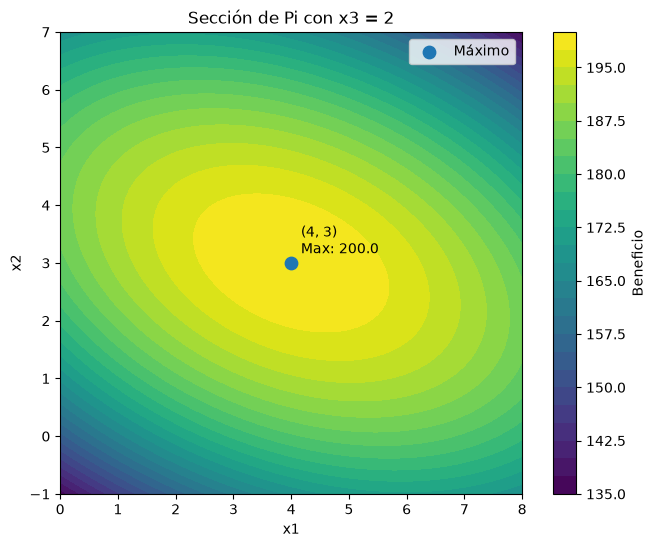

In [15]:
# Una función de tres entradas necesitaría cuatro dimensiones para representarse.
# Fijamos x3 en su valor óptimo y graficamos una sección en (x1, x2).
x3_star = solucion_3[x3]
beneficio_3_seccion = sp.simplify(beneficio_3.subs(x3, x3_star))
beneficio_3_seccion_np = sp.lambdify((x1, x2), beneficio_3_seccion, 'numpy')

x1_valores = np.linspace(0, 8, 180)
x2_valores = np.linspace(-1, 7, 180)
X1, X2 = np.meshgrid(x1_valores, x2_valores)
Z3 = beneficio_3_seccion_np(X1, X2)

plt.figure(figsize=(8, 6))
contorno_3 = plt.contourf(X1, X2, Z3, levels=25, cmap='viridis')
plt.scatter(4, 3, s=80, label='Máximo')
plt.annotate(f'(4, 3)\nMax: {float(beneficio_star_3):.1f}', (4, 3), xytext=(7, 7), textcoords='offset points')
plt.title('Sección de Pi con x3 = 2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar(contorno_3, label='Beneficio')
plt.legend()
plt.show()


# 4. Funciones vectoriales $f:\mathbb{R}^n\to\mathbb{R}^m$

Una función vectorial tiene la forma

$$
f(\mathbf{x})=
\begin{pmatrix}
f_1(\mathbf{x})\\
\vdots\\
f_m(\mathbf{x})
\end{pmatrix}.
$$

Su primera derivada es la Jacobiana

$$
J_f(\mathbf{x})=
\begin{pmatrix}
\nabla f_1(\mathbf{x})^T\\
\vdots\\
\nabla f_m(\mathbf{x})^T
\end{pmatrix}
\in\mathbb{R}^{m\times n}.
$$

Su segunda derivada puede entenderse como una colección de $m$ Hessianas:

$$
H_{f_1},\ldots,H_{f_m},
\qquad H_{f_i}\in\mathbb{R}^{n\times n}.
$$

La optimización clásica necesita una función objetivo escalar. Por eso se requiere una regla de preferencia, por ejemplo una escalarización.

## 4.1. Escalarización por suma ponderada

Sea

$$
\mathbf{w}=
\begin{pmatrix}
w_1\\ \vdots\\ w_m
\end{pmatrix},
\qquad
w_i\ge0,
\qquad
\sum_{i=1}^m w_i=1.
$$

Definimos

$$
\boxed{
F_{\mathbf{w}}(\mathbf{x})
=\mathbf{w}^Tf(\mathbf{x})
=\sum_{i=1}^m w_i f_i(\mathbf{x})
}
$$

Dimensiones del valor escalarizado:

$$
\underbrace{\mathbf{w}^T}_{1\times m}
\underbrace{f(\mathbf{x})}_{m\times1}
\;\in\;\mathbb{R}.
$$

Primera derivada:

$$
\boxed{
\nabla F_{\mathbf{w}}(\mathbf{x})
=J_f(\mathbf{x})^T\mathbf{w}
}
$$

con dimensiones

$$
\underbrace{J_f^T}_{n\times m}
\underbrace{\mathbf{w}}_{m\times1}
=\underbrace{\nabla F_{\mathbf{w}}}_{n\times1}.
$$

Segunda derivada:

$$
\boxed{
H_{F_{\mathbf{w}}}(\mathbf{x})
=\sum_{i=1}^m w_iH_{f_i}(\mathbf{x})
\in\mathbb{R}^{n\times n}.
}
$$

## 4.2. ¿Cómo se eligen los pesos?

Los pesos representan prioridades y no deberían fijarse sin contexto. Pueden provenir de:

- juicio de expertos o responsables de decisión;
- comparación por pares;
- escenarios de sensibilidad;
- preferencias reveladas;
- normalización y análisis de las escalas de los objetivos.

Si un objetivo se mide en miles y otro entre 0 y 1, el primero puede dominar aunque su peso sea pequeño. Por eso los objetivos deben tener unidades comparables o normalizarse.

### Nota sobre Pareto y convexidad

Para una formulación de **minimización**, si todos los pesos son estrictamente positivos, una solución de la suma ponderada es Pareto eficiente. Existe un resultado análogo para maximización.

Bajo supuestos de convexidad, la suma ponderada recupera los puntos eficientes **soportados**. Cuando el frente es no convexo, puede omitir puntos Pareto eficientes no soportados.

No existe, en general, una biyección automática entre pesos y puntos Pareto:

- distintos pesos pueden producir el mismo óptimo;
- un mismo peso puede tener varios óptimos.

La unicidad para un peso dado se obtiene, por ejemplo, cuando la función escalarizada es estrictamente convexa en minimización o estrictamente cóncava en maximización.

## 4.3. Ejemplo $\mathbb{R}^2\to\mathbb{R}^2$ con escalarización

Una organización elige dos decisiones, $x$ e $y$, y evalúa dos objetivos ya expresados en escalas comparables:

- $f_1(x,y)$: desempeño económico;
- $f_2(x,y)$: desempeño de sostenibilidad.

Definimos

$$
f(x,y)
=
\begin{pmatrix}
f_1(x,y)\\
f_2(x,y)
\end{pmatrix}
=
\begin{pmatrix}
120-(x-5)^2-2(y-2)^2\\
100-2(x-2)^2-(y-5)^2
\end{pmatrix}.
$$

Cada objetivo por separado prefiere un punto diferente:

$$
f_1:\ (5,2),
\qquad
f_2:\ (2,5).
$$

In [16]:
# Componentes de la función vectorial.
f1 = 120 - (x - 5)**2 - 2*(y - 2)**2
f2 = 100 - 2*(x - 2)**2 - (y - 5)**2

# f(x, y): 2 x 1.
f_vector = sp.Matrix([f1, f2])

# Jacobiana: 2 x 2.
J_f = f_vector.jacobian((x, y))

# Una Hessiana 2 x 2 por componente.
H_f1 = sp.hessian(f1, (x, y))
H_f2 = sp.hessian(f2, (x, y))

print('f(x, y):')
display(f_vector)
print('Dimensión de f:', f_vector.shape)

print('Jacobiana:')
display(J_f)
print('Dimensión de J_f:', J_f.shape)

print('Hessiana de f1:')
display(H_f1)
print('Hessiana de f2:')
display(H_f2)


f(x, y):


⎡         2            2      ⎤
⎢- (x - 5)  - 2⋅(y - 2)  + 120⎥
⎢                             ⎥
⎢           2          2      ⎥
⎣- 2⋅(x - 2)  - (y - 5)  + 100⎦

Dimensión de f: (2, 1)
Jacobiana:


⎡10 - 2⋅x  8 - 4⋅y ⎤
⎢                  ⎥
⎣8 - 4⋅x   10 - 2⋅y⎦

Dimensión de J_f: (2, 2)
Hessiana de f1:


⎡-2  0 ⎤
⎢      ⎥
⎣0   -4⎦

Hessiana de f2:


⎡-4  0 ⎤
⎢      ⎥
⎣0   -2⎦

Elegimos

$$
w_1=0.6,
\qquad
w_2=0.4.
$$

El objetivo económico recibe una prioridad ligeramente mayor.

In [17]:
# Pesos como vector columna 2 x 1.
w1 = sp.Rational(3, 5)
w2 = sp.Rational(2, 5)
pesos = sp.Matrix([w1, w2])

# El producto pesos.T * f_vector tiene dimensión 1 x 1.
F_matriz = pesos.T * f_vector

# Extraemos el único elemento para trabajar con una expresión escalar.
F = sp.expand(F_matriz[0])

print('Vector de pesos:')
display(pesos)
print('Dimensión de w:', pesos.shape)
print('Dimensión de w.T:', pesos.T.shape)
print('Dimensión de f:', f_vector.shape)
print('Dimensión de w.T * f:', F_matriz.shape)
print('Función escalarizada F(x, y):')
display(F)


Vector de pesos:


⎡3/5⎤
⎢   ⎥
⎣2/5⎦

Dimensión de w: (2, 1)
Dimensión de w.T: (1, 2)
Dimensión de f: (2, 1)
Dimensión de w.T * f: (1, 1)
Función escalarizada F(x, y):


     2             2            
  7⋅x    46⋅x   8⋅y    44⋅y     
- ──── + ──── - ──── + ──── + 79
   5      5      5      5       

## 4.4. Primera derivada de la función escalarizada

Comprobaremos por dos caminos:

$$
\nabla F=J_f^T\mathbf{w}.
$$

In [18]:
# Camino 1: derivar F directamente.
grad_F_directo = sp.Matrix([
    sp.diff(F, x),
    sp.diff(F, y)
])

# Camino 2: Jacobiana transpuesta por los pesos.
grad_F_jacobiana = J_f.T * pesos

verificacion_gradiente = sp.simplify(grad_F_directo - grad_F_jacobiana)

print('Dimensión de J_f.T:', J_f.T.shape)
print('Dimensión de w:', pesos.shape)
print('Dimensión de J_f.T * w:', grad_F_jacobiana.shape)
print('Gradiente directo:')
display(grad_F_directo)
print('Gradiente mediante J_f.T * w:')
display(grad_F_jacobiana)
print('Diferencia:')
display(verificacion_gradiente)

assert verificacion_gradiente == sp.zeros(2, 1)


Dimensión de J_f.T: (2, 2)
Dimensión de w: (2, 1)
Dimensión de J_f.T * w: (2, 1)
Gradiente directo:


⎡46   14⋅x⎤
⎢── - ────⎥
⎢5     5  ⎥
⎢         ⎥
⎢44   16⋅y⎥
⎢── - ────⎥
⎣5     5  ⎦

Gradiente mediante J_f.T * w:


⎡46   14⋅x⎤
⎢── - ────⎥
⎢5     5  ⎥
⎢         ⎥
⎢44   16⋅y⎥
⎢── - ────⎥
⎣5     5  ⎦

Diferencia:


⎡0⎤
⎢ ⎥
⎣0⎦

## 4.5. Segunda derivada de la función escalarizada

Comprobaremos

$$
H_F=w_1H_{f_1}+w_2H_{f_2}.
$$

In [19]:
# Camino 1: Hessiana directa.
H_F_directa = sp.hessian(F, (x, y))

# Camino 2: combinación ponderada.
H_F_componentes = w1*H_f1 + w2*H_f2

verificacion_H = sp.simplify(H_F_directa - H_F_componentes)

print('Hessiana directa:')
display(H_F_directa)
print('Dimensión:', H_F_directa.shape)
print('Combinación ponderada:')
display(H_F_componentes)
print('Diferencia:')
display(verificacion_H)

assert verificacion_H == sp.zeros(2, 2)


Hessiana directa:


⎡-14/5    0  ⎤
⎢            ⎥
⎣  0    -16/5⎦

Dimensión: (2, 2)
Combinación ponderada:


⎡-14/5    0  ⎤
⎢            ⎥
⎣  0    -16/5⎦

Diferencia:


⎡0  0⎤
⎢    ⎥
⎣0  0⎦

## 4.6. Optimizar la función escalarizada

Después de escalarizar, volvemos a un problema

$$
F:\mathbb{R}^2\to\mathbb{R}.
$$

Por tanto, podemos aplicar CPO, menores líderes y autovalores.

In [20]:
# CPO.
soluciones_F = sp.solve(list(grad_F_directo), (x, y), dict=True)
solucion_F = soluciones_F[0]

# Menores líderes de la Hessiana.
Delta1_F = sp.simplify(H_F_directa[:1, :1].det())
Delta2_F = sp.simplify(H_F_directa[:2, :2].det())

# Autovalores.
H_F_np = np.array(H_F_directa.tolist(), dtype=float)
autovalores_F = np.linalg.eigvalsh(H_F_np)

# Punto y valor óptimos.
x_star_F = sp.simplify(solucion_F[x])
y_star_F = sp.simplify(solucion_F[y])
F_star = sp.simplify(F.subs(solucion_F))

print('Punto crítico:')
print(f"x: {float(solucion_F[x]):.1f}, y: {float(solucion_F[y]):.1f}")
print(f'Delta_1 = {float(Delta1_F):.1f}')
print(f'Delta_2 = {float(Delta2_F):.1f}')
print(f'Autovalores: [{autovalores_F[0]:.1f}, {autovalores_F[1]:.1f}]')
print(f'Valor de F en el óptimo: {float(F_star):.1f}')
print(f'f1 en el compromiso: {float(sp.simplify(f1.subs(solucion_F))):.1f}')
print(f'f2 en el compromiso: {float(sp.simplify(f2.subs(solucion_F))):.1f}')

assert x_star_F == sp.Rational(23, 7)
assert y_star_F == sp.Rational(11, 4)


Punto crítico:
x: 3.3, y: 2.8
Delta_1 = -2.8
Delta_2 = 9.0
Autovalores: [-3.2, -2.8]
Valor de F en el óptimo: 106.2
f1 en el compromiso: 115.9
f2 en el compromiso: 91.6


Como $\Delta_1<0$, $\Delta_2>0$ y ambos autovalores son negativos, $H_F\prec0$. La función escalarizada es estrictamente cóncava y el compromiso es su máximo global único.

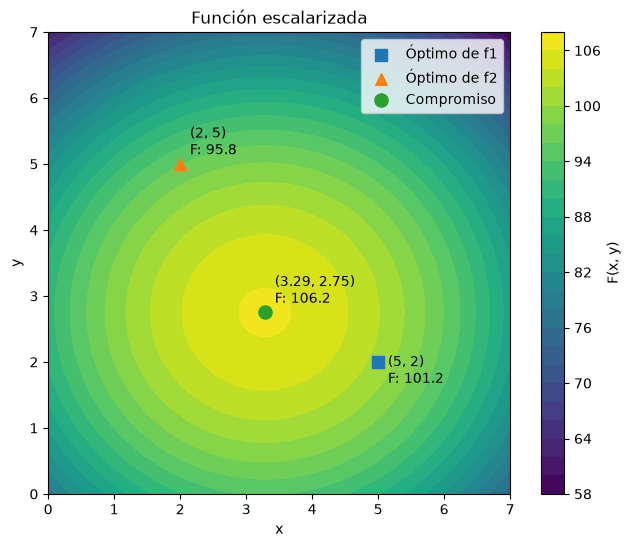

In [21]:
# Curvas de nivel de la función escalarizada.
F_np = sp.lambdify((x, y), F, 'numpy')

x_F_valores = np.linspace(0, 7, 180)
y_F_valores = np.linspace(0, 7, 180)
X_F, Y_F = np.meshgrid(x_F_valores, y_F_valores)
Z_F = F_np(X_F, Y_F)

# Calculamos el valor de F en los tres puntos.
val_f1 = float(F_np(5, 2))
val_f2 = float(F_np(2, 5))
val_comp = float(F_star)

plt.figure(figsize=(8, 6))
contorno_F = plt.contourf(X_F, Y_F, Z_F, levels=25, cmap='viridis')

# Óptimo de f1
plt.scatter(5, 2, s=70, marker='s', label='Óptimo de f1')
plt.annotate(f'(5, 2)\nF: {val_f1:.1f}', (5, 2),
             xytext=(7, -15), textcoords='offset points')

# Óptimo de f2
plt.scatter(2, 5, s=70, marker='^', label='Óptimo de f2')
plt.annotate(f'(2, 5)\nF: {val_f2:.1f}', (2, 5),
             xytext=(7, 7), textcoords='offset points')

# Punto de compromiso
plt.scatter(float(x_star_F), float(y_star_F), s=90, label='Compromiso')
plt.annotate(
    f'({float(x_star_F):.2f}, {float(y_star_F):.2f})\nF: {val_comp:.1f}',
    (float(x_star_F), float(y_star_F)),
    xytext=(7, 7), textcoords='offset points'
)

plt.title('Función escalarizada')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar(contorno_F, label='F(x, y)')
plt.legend()
plt.show()


## 4.7. Sensibilidad a los pesos

Resolveremos varios escenarios con $w_2=1-w_1$. Los pesos se mantienen estrictamente positivos para representar verdaderos compromisos entre ambos objetivos.

In [22]:
# Valores de w1 entre 0.05 y 0.95.
pesos_w1 = np.linspace(0.05, 0.95, 19)

x_optimos = []
y_optimos = []
f1_optimos = []
f2_optimos = []

for peso_1_num in pesos_w1:
    peso_2_num = 1.0 - peso_1_num

    # Función escalarizada para este escenario.
    F_caso = peso_1_num*f1 + peso_2_num*f2

    # CPO.
    grad_F_caso = [sp.diff(F_caso, x), sp.diff(F_caso, y)]
    solucion_caso = sp.solve(grad_F_caso, (x, y), dict=True)[0]

    x_caso = float(solucion_caso[x])
    y_caso = float(solucion_caso[y])

    x_optimos.append(x_caso)
    y_optimos.append(y_caso)
    f1_optimos.append(float(f1.subs(solucion_caso)))
    f2_optimos.append(float(f2.subs(solucion_caso)))

print('Primer escenario:')
print('w1 =', pesos_w1[0], 'x* =', x_optimos[0], 'y* =', y_optimos[0])
print('Último escenario:')
print('w1 =', pesos_w1[-1], 'x* =', x_optimos[-1], 'y* =', y_optimos[-1])


Primer escenario:
w1 = 0.05 x* = 2.076923076923077 y* = 4.714285714285714
Último escenario:
w1 = 0.95 x* = 4.714285714285714 y* = 2.076923076923077


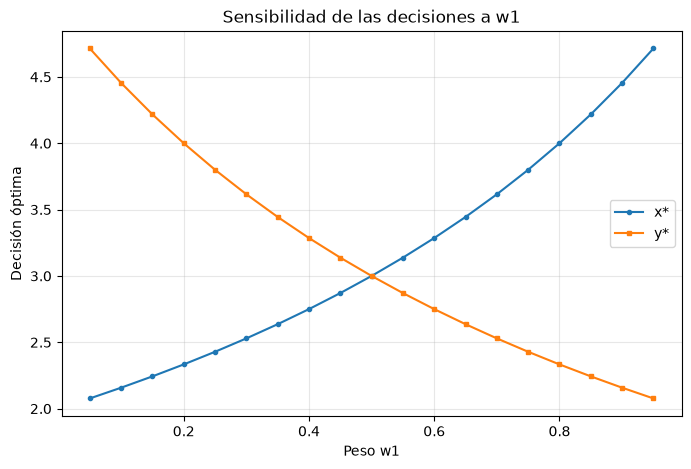

In [23]:
# Trayectoria de las decisiones óptimas al cambiar los pesos.
plt.figure(figsize=(8, 5))
plt.plot(pesos_w1, x_optimos, marker='o', markersize=3, label='x*')
plt.plot(pesos_w1, y_optimos, marker='s', markersize=3, label='y*')
plt.title('Sensibilidad de las decisiones a w1')
plt.xlabel('Peso w1')
plt.ylabel('Decisión óptima')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


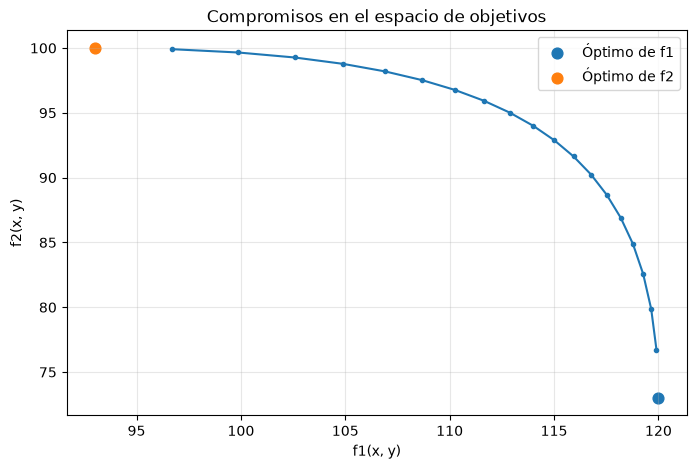

In [24]:
# Puntos de compromiso en el espacio de objetivos.
plt.figure(figsize=(8, 5))
plt.plot(f1_optimos, f2_optimos, marker='o', markersize=3)
plt.scatter(120, float(f2.subs({x: 5, y: 2})), s=60, label='Óptimo de f1')
plt.scatter(float(f1.subs({x: 2, y: 5})), 100, s=60, label='Óptimo de f2')
plt.title('Compromisos en el espacio de objetivos')
plt.xlabel('f1(x, y)')
plt.ylabel('f2(x, y)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# 5. Módulo opcional: métodos numéricos de optimización

Hasta aquí resolvimos los problemas de forma analítica:

$$
\nabla F(\mathbf{x})=\mathbf{0}.
$$

Este enfoque es ideal para funciones pequeñas porque permite:

- obtener una solución exacta;
- comprender las CPO y CSO;
- clasificar el punto mediante la Hessiana;
- analizar convexidad o concavidad.

Sin embargo, puede dejar de ser práctico cuando:

- el sistema de CPO no tiene solución cerrada;
- existen cientos, miles o millones de variables;
- la función contiene composiciones muy complejas;
- la función se calcula a partir de una gran base de datos;
- formar o invertir la Hessiana es demasiado costoso.

En estos casos se utilizan métodos iterativos.

## 5.1. ¿Por qué el gradiente indica una dirección de cambio?

Por la aproximación lineal,

$$
F(\mathbf{x}+\mathbf{s})
\approx
F(\mathbf{x})+\nabla F(\mathbf{x})^T\mathbf{s}.
$$

Para disminuir $F$, elegimos un paso opuesto al gradiente. Para aumentarla, elegimos un paso en la misma dirección.

### Descenso para minimizar

$$
\boxed{
\mathbf{x}_{k+1}
=\mathbf{x}_k-\alpha_k\nabla F(\mathbf{x}_k)
}
$$

### Ascenso para maximizar

$$
\boxed{
\mathbf{x}_{k+1}
=\mathbf{x}_k+\alpha_k\nabla F(\mathbf{x}_k)
}
$$

Dimensiones:

$$
\underbrace{\mathbf{x}_k}_{n\times1}
\pm
\underbrace{\alpha_k}_{\text{escalar}}
\underbrace{\nabla F(\mathbf{x}_k)}_{n\times1}
\;=\;
\underbrace{\mathbf{x}_{k+1}}_{n\times1}.
$$

El tamaño del paso $\alpha_k>0$ controla cuánto se avanza en cada iteración.

## 5.2. Comparación: solución analítica y gradiente

| Aspecto | Método analítico | Método de gradiente |
|---|---|---|
| Resultado | exacto, si existe forma cerrada | aproximado |
| Operación principal | resolver $\nabla F=0$ | evaluar repetidamente $\nabla F$ |
| Segunda derivada | útil para clasificar | no es necesaria en descenso básico |
| Escala del problema | pequeña o moderada | puede ser muy grande |
| Dependencia del punto inicial | normalmente no en problemas simples | sí |
| Parámetros del método | pocos | paso, iteraciones, tolerancia |
| Garantía global | con convexidad/concavidad | con supuestos y elección adecuada del paso |

El gradiente no reemplaza la teoría clásica. La utiliza como fundamento y extiende su alcance computacional.

## 5.3. Ejemplo opcional: ascenso por gradiente

Aplicaremos ascenso por gradiente a la función de beneficio de dos productos, cuya solución exacta ya conocemos:

$$
(x^*,y^*)=(5,3).
$$

Esto permite comparar la solución iterativa con la solución obtenida mediante `sp.solve()`.

In [25]:
# Convertimos el gradiente simbólico en una función numérica.
grad_beneficio_2_np = sp.lambdify((x, y), grad_beneficio_2, 'numpy')

# Punto inicial, paso e iteraciones.
punto_gradiente = np.array([0.0, 0.0])
alpha = 0.10
numero_iteraciones = 30

# Guardamos la trayectoria.
trayectoria = [punto_gradiente.copy()]

for k in range(numero_iteraciones):
    gradiente_actual = np.array(
        grad_beneficio_2_np(*punto_gradiente),
        dtype=float
    ).reshape(2)

    # Ascenso porque se maximiza el beneficio.
    punto_gradiente = punto_gradiente + alpha*gradiente_actual
    trayectoria.append(punto_gradiente.copy())

trayectoria = np.array(trayectoria)

print('Punto aproximado:', punto_gradiente)
print('Solución exacta: [5, 3]')
print('Error euclídeo:', np.linalg.norm(punto_gradiente - np.array([5.0, 3.0])))


Punto aproximado: [4.99876206 3.00123794]
Solución exacta: [5, 3]
Error euclídeo: 0.0017507115929618609


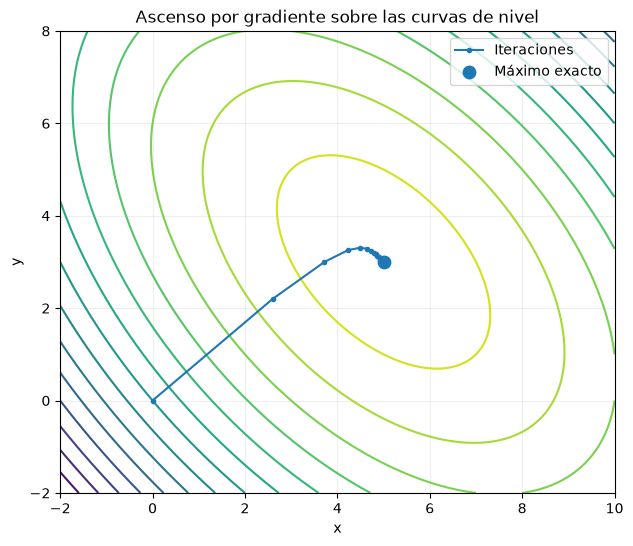

In [26]:
# Trayectoria sobre las curvas de nivel.
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=20)
plt.plot(trayectoria[:, 0], trayectoria[:, 1], marker='o', markersize=3,
         label='Iteraciones')
plt.scatter(5, 3, s=80, label='Máximo exacto')
plt.title('Ascenso por gradiente sobre las curvas de nivel')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(alpha=0.2)
plt.legend()
plt.show()


# 6. Resumen comparativo

| Caso | Valor | Primera derivada | Segunda derivada | Optimización clásica |
|---|---:|---|---|---|
| $f:\mathbb{R}\to\mathbb{R}$ | escalar | $f'$ escalar | $f''$ escalar | $f'=0$ y signo de $f''$ |
| $F:\mathbb{R}^2\to\mathbb{R}$ | escalar | $\nabla F$: $2\times1$ | $H_F$: $2\times2$ | CPO y criterio $D$ |
| $F:\mathbb{R}^n\to\mathbb{R}$ | escalar | $\nabla F$: $n\times1$ | $H_F$: $n\times n$ | CPO, menores o autovalores |
| $f:\mathbb{R}^n\to\mathbb{R}^m$ | $m\times1$ | $J_f$: $m\times n$ | $m$ Hessianas $n\times n$ | requiere escalarización u otro criterio multiobjetivo |

## Ruta analítica común

```python
# 1. Declarar símbolos.
# 2. Definir la función escalar.
# 3. Calcular el gradiente con sp.diff().
# 4. Resolver las CPO con sp.solve().
# 5. Calcular la Hessiana con sp.hessian().
# 6. Revisar menores principales líderes.
# 7. Comprobar autovalores con np.linalg.eigvalsh().
# 8. Evaluar y graficar el óptimo.
```

## Ruta para una función vectorial

```python
# 1. Construir f_vector = sp.Matrix([f1, ..., fm]).
# 2. Calcular J_f = f_vector.jacobian(variables).
# 3. Calcular una Hessiana por componente.
# 4. Elegir y justificar los pesos.
# 5. Construir F = (w.T * f_vector)[0].
# 6. Verificar grad_F = J_f.T * w.
# 7. Verificar H_F = sum(w_i * H_fi).
# 8. Optimizar F como función escalar.
```

# 7. Errores frecuentes

1. **Confundir gradiente y Jacobiana.** El gradiente de una función escalar es $n\times1$; la Jacobiana de una función vectorial es $m\times n$.
2. **Ignorar las dimensiones.** Antes de multiplicar matrices, compruebe que las dimensiones interiores coincidan.
3. **Creer que la CPO clasifica el punto.** $\nabla F=0$ solo identifica candidatos.
4. **Concluir indefinición porque falla el patrón de menores líderes.** La matriz también podría ser semidefinida.
5. **Usar `eigvals` en una Hessiana simétrica.** `eigvalsh` aprovecha la simetría y devuelve autovalores reales.
6. **Elegir pesos sin comparar escalas.** Las unidades pueden dominar el resultado.
7. **Suponer que la suma ponderada recupera cualquier frente no convexo.** Puede omitir puntos Pareto no soportados.
8. **Usar descenso para maximizar.** Para beneficio o utilidad se usa ascenso, o se minimiza el negativo.
9. **Presentar el gradiente iterativo antes de dominar CPO y CSO.** El algoritmo se entiende mejor después de la teoría analítica.
10. **Esperar una solución exacta del gradiente numérico.** Es un procedimiento aproximado y depende del paso y del punto inicial.

# 8. Práctica autónoma

## A. Función $\mathbb{R}\to\mathbb{R}$

Optimice y grafique

$$
g(q)=-2q^2+48q-80.
$$

## B. Función $\mathbb{R}^2\to\mathbb{R}$

Optimice, calcule $\Delta_1$, $\Delta_2$, los autovalores y grafique

$$
g(x,y)=-x^2-2y^2-xy+10x+12y.
$$

## C. Función $\mathbb{R}^3\to\mathbb{R}$

Optimice

$$
g(x_1,x_2,x_3)
=150-(x_1-2)^2-(x_2-4)^2-2(x_3-1)^2.
$$

Compruebe la clasificación mediante:

1. los tres menores principales líderes;
2. los tres autovalores.

## D. Función vectorial

En el ejemplo de escalarización:

1. cambie los pesos a $w_1=0.3$ y $w_2=0.7$;
2. compruebe las dimensiones de $\mathbf{w}^Tf$, $J_f^T\mathbf{w}$ y $H_F$;
3. resuelva el nuevo óptimo;
4. explique hacia cuál objetivo individual se mueve la solución.

## E. Módulo opcional

Cambie el tamaño de paso del ascenso por gradiente a

$$
\alpha\in\{0.02,0.10,0.30,0.40\}
$$

y compare las trayectorias. Explique qué ocurre cuando el paso es demasiado grande.

In [27]:
# Comprobación final de los resultados principales.
assert q_star == 20
assert beneficio_star_q == 300

assert solucion_2 == {x: 5, y: 3}
assert beneficio_star_2 == 98

assert solucion_3 == {x1: 4, x2: 3, x3: 2}
assert beneficio_star_3 == 200

assert solucion_F == {x: sp.Rational(23, 7), y: sp.Rational(11, 4)}

print('Todas las comprobaciones del notebook se ejecutaron correctamente.')


Todas las comprobaciones del notebook se ejecutaron correctamente.
